# Excercises week 2


### Excercise 2.1.a

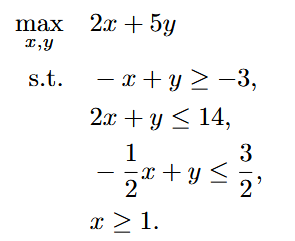

Solve the optimisation problem graphically (pen and paper or on your laptop). Note that it is a
maximisation problem, whereas we will mostly work with minimisations. Reformulate as a minimisation
problem.


### Solution
The optimal point is (5,4), which is the top right corner in the picture below
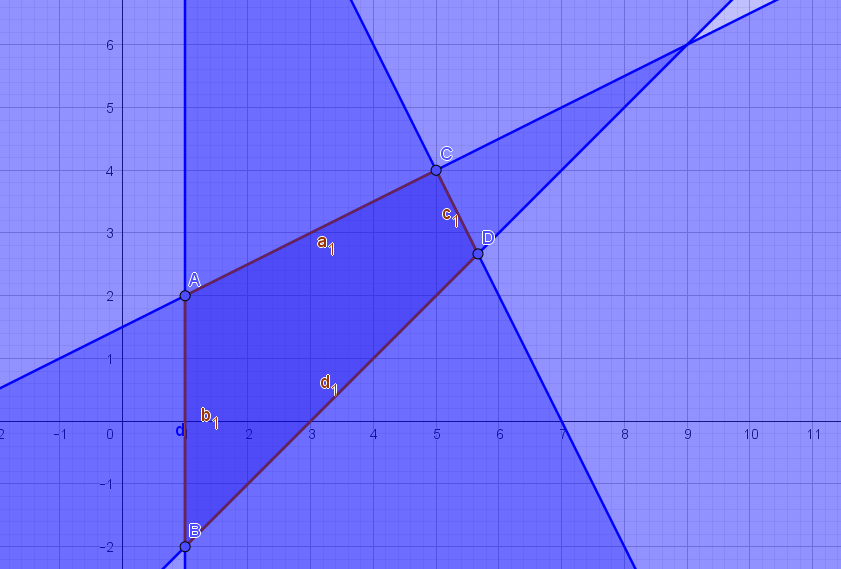



### 2.1.b
Return to the original formulation. Indicate which constraints are binding and calculate the values of
the Lagrange multipliers.

### Solution


Constraints 2 and 3 are binding the optimal objective
See Ipad drawing

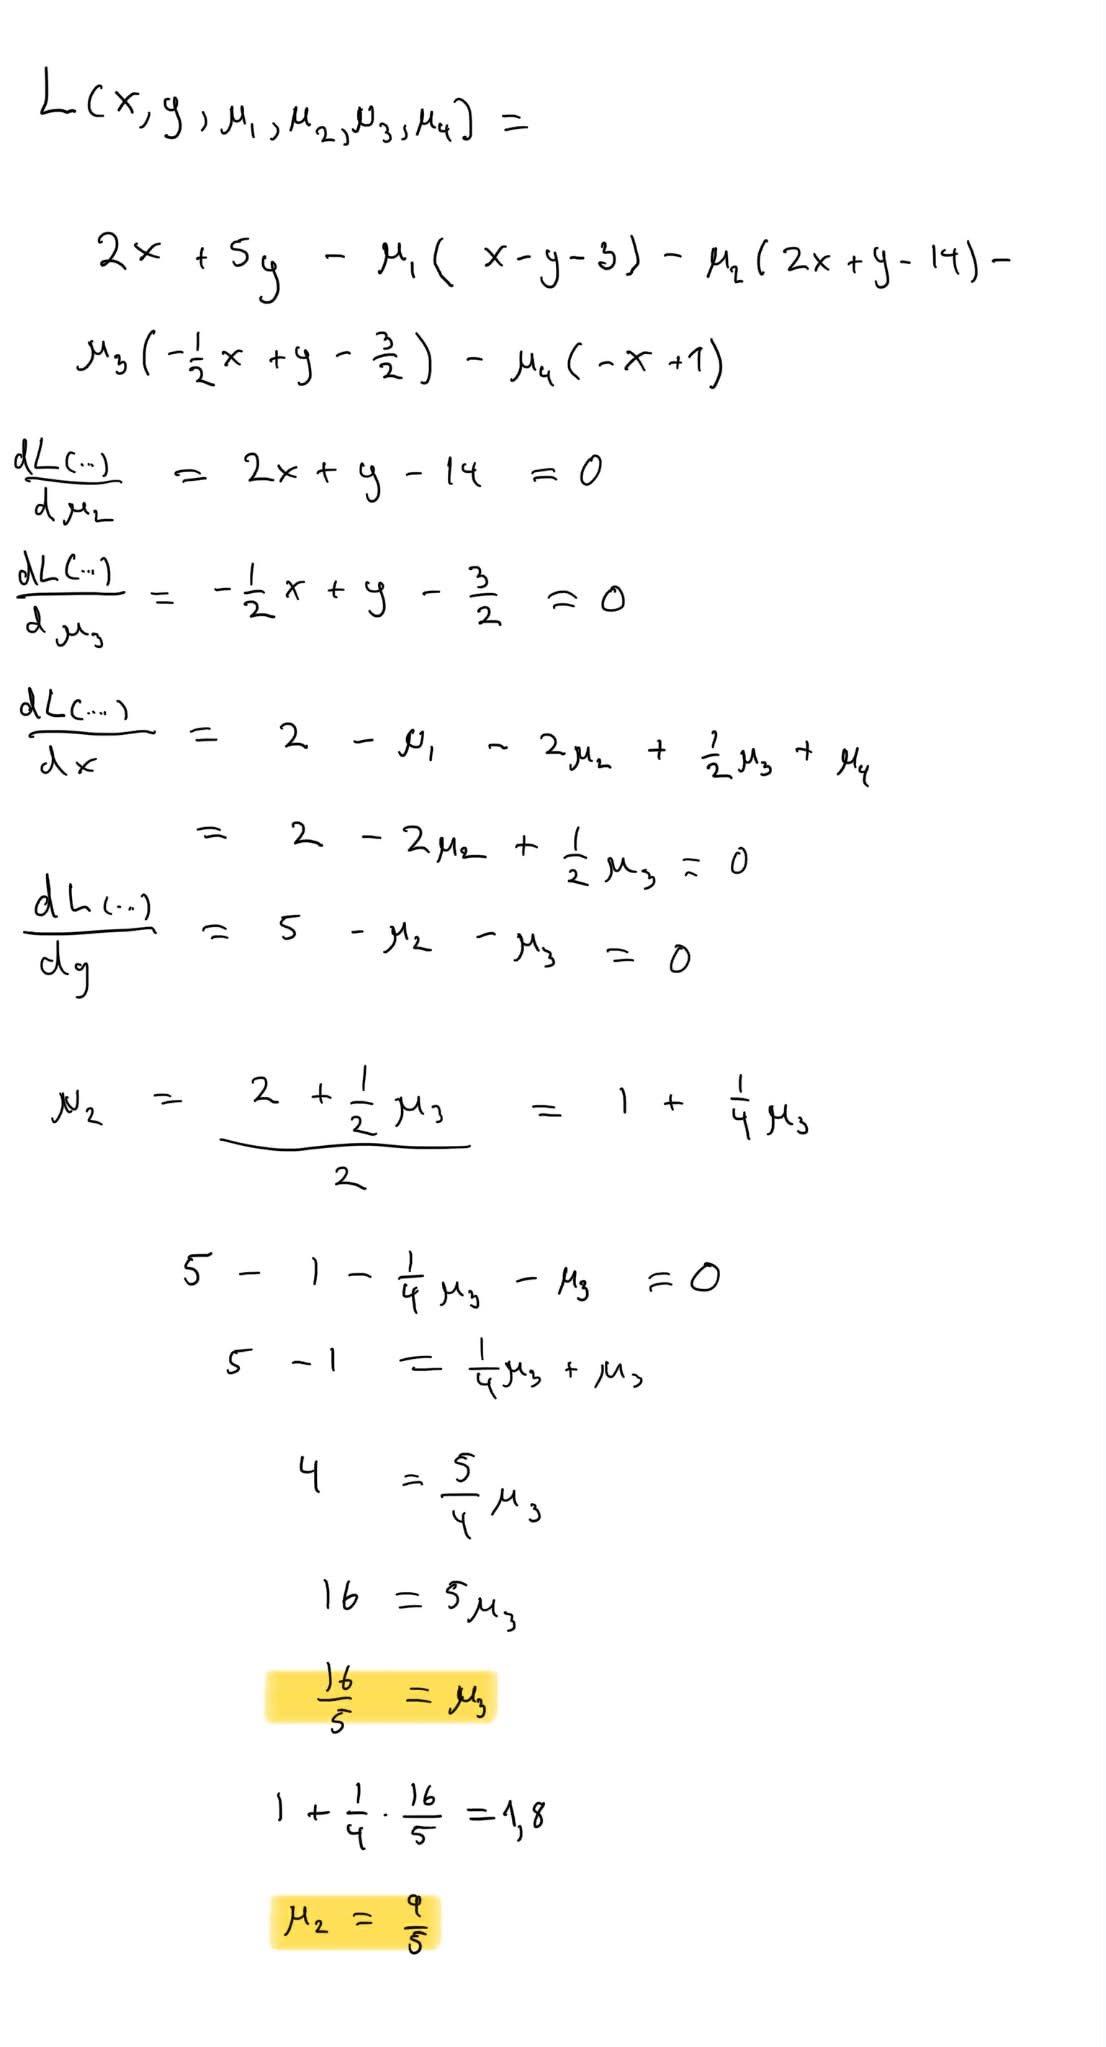

$\mu_2 = 9/5$ 


$\mu_3 = 16/5$

### 2.1.c
Now there are two points with the same optimal objective value
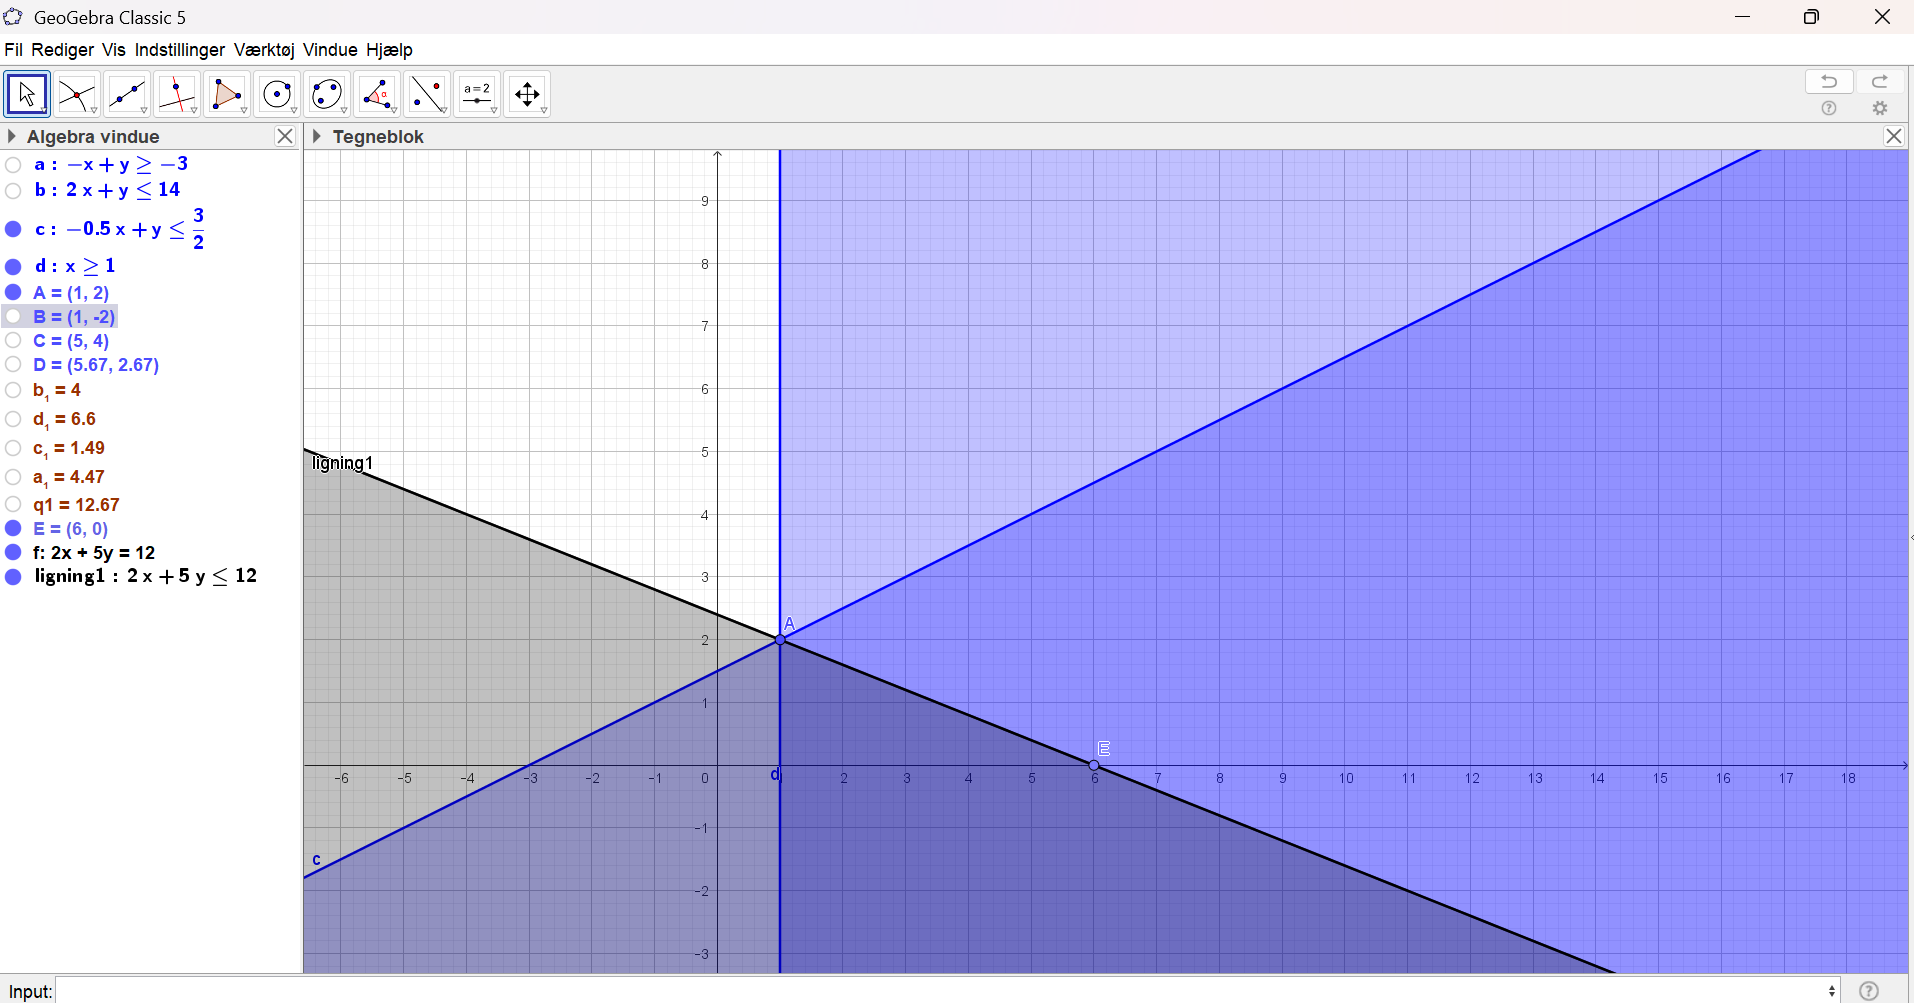

### 2.2.a
For this problem you will need to use the Python package linopy. Start with the introduction
to linopy: https://aleks-g.github.io/integrated-energy-grids/intro-linopy.html.
Consider the following economic dispatch problem:

• we have three generators: solar, wind and gas

• solar and wind have no marginal costs, and gas has fuel costs of 60 EUR/MWh.

• we need to cover demand of 13.2 MWh

• the installed capacities are 15 MW, 20 MW and 20 MW for wind, solar, and gas, respectively

• assume the capacity factor for solar is 0.17 and for wind 0.33.

Use linopy to define and solve the LP and find the optimal solution as well as reading out the Lagrange
multipliers as defined in the lecture.

In [1]:
import linopy
import pandas as pd

# Define the model
m = linopy.Model()

# Define capacity factors for wind and solar
cf_w = 0.33
cw_s = 0.17

# Define the demand 
demand = 13.2 # MWh

# Define variables for wind, solar and gas generation
w = m.add_variables(lower= 0, upper=15*cf_w, name = "wind") #MW
s = m.add_variables(lower= 0, upper=20*cw_s, name = "solar") #MW
g = m.add_variables(lower=0, upper=20, name = "gas") #MW

# Define the objective function 
m.add_objective(0 * w + 0* s + g * 60, sense = "min") # Minimize cost of generation

# Define the constraint for meeting demand
demand_con = m.add_constraints( w + s + g >= demand)

# solve the model
m.solve(solver_name = "gurobi")

# Print the optimal generation from wind, solar and gas
results = pd.DataFrame([{
    "wind": float(m.solution["wind"]),
    "solar": float(m.solution["solar"]),
    "gas":  float(m.solution["gas"]),
}])
print(results)

# Print dual variables as dataframe
mp = float(demand_con.dual)

print(f"Marginal price (dual value): {mp}")






Set parameter Username
Set parameter LicenseID to value 2745305
Academic license - for non-commercial use only - expires 2026-11-26
Read LP format model from file C:\Users\frede\AppData\Local\Temp\linopy-problem-4w91dfin.lp
Reading time = 0.00 seconds
obj: 1 rows, 3 columns, 3 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 3 columns and 3 nonzeros (Min)
Model fingerprint: 0xc63df1ea
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+01, 6e+01]
  Bounds range     [3e+00, 2e+01]
  RHS range        [1e+01, 1e+01]

Presolve removed 1 rows and 3 columns
Presolve time: 0.03s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   

### 2b
Open problem2 2b.csv, and use the values as inputs for capacity factors as well as demand in the
dispatch problem. Solve the LP with linopy.

In [8]:
import linopy
import pandas as pd

df = pd.read_csv("problem2_2b.csv")

# Proper hour index (named)
hours = pd.RangeIndex(df.shape[0], name="hour")

m2c = linopy.Model()

techs = pd.Index(["wind", "solar", "gas"], name="tech")

cost = pd.Series([0, 0, 60], index=techs)

# Align input series to hours
demand = pd.Series(df["demand [MWh]"].values, index=hours)
cf_w   = pd.Series(df["wind cf"].values, index=hours)
cf_s   = pd.Series(df["solar cf"].values, index=hours)

# Decision variables: gen[hour, tech]
gen = m2c.add_variables(lower=0, coords=[hours, techs], name="gen")

# Objective
m2c.add_objective((gen * cost).sum(), sense="min")

# Capacity constraints (one per hour)
m2c.add_constraints(gen.sel(tech="wind") <= 15 * cf_w, name="cap_wind")
m2c.add_constraints(gen.sel(tech="solar") <= 20 * cf_s, name="cap_solar")
m2c.add_constraints(gen.sel(tech="gas")  <= 20,         name="cap_gas")

# Demand constraint (one per hour) — STORE it so you can read duals
demand_con = m2c.add_constraints(gen.sum(dim="tech") >= demand, name="demand")

# Solve
m2c.solve(solver_name="gurobi")

# ---- Results ----
# Solution is for "gen" (hour x tech)
gen_sol = m2c.solution["gen"]

# As a tidy dataframe with columns wind/solar/gas and index hour
results = gen_sol.to_pandas() # or gen_sol.to_dataframe().reset_index()
print(results)

# ---- Duals / marginal prices ----
# This is a vector over hour
mp = demand_con.dual.to_pandas()
print("Marginal price per hour:")
print(mp)


Set parameter Username
Set parameter LicenseID to value 2745305
Academic license - for non-commercial use only - expires 2026-11-26
Read LP format model from file C:\Users\frede\AppData\Local\Temp\linopy-problem-l69sgt2a.lp
Reading time = 0.00 seconds
obj: 16 rows, 12 columns, 24 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 16 rows, 12 columns and 24 nonzeros (Min)
Model fingerprint: 0x04fd9fbd
Model has 4 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-01, 2e+01]

Presolve removed 16 rows and 12 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
   

In [9]:
import linopy
import pandas as pd

df = pd.read_csv("problem2_2c.csv")

# Proper hour index (named)
hours = pd.RangeIndex(df.shape[0], name="hour")

m2d = linopy.Model()

techs = pd.Index(["wind", "solar", "gas"], name="tech")

cost = pd.Series([0, 0, 60], index=techs)

# Align input series to hours
demand = pd.Series(df["demand [MWh]"].values, index=hours)
cf_w   = pd.Series(df["wind cf"].values, index=hours)
cf_s   = pd.Series(df["solar cf"].values, index=hours)

# Decision variables: gen[hour, tech]
gen = m2d.add_variables(lower=0, coords=[hours, techs], name="gen")
    
# Objective
m2d.add_objective((gen * cost).sum(), sense="min")

# Capacity constraints (one per hour)
m2d.add_constraints(gen.sel(tech="wind") <= 15 * cf_w, name="cap_wind")
m2d.add_constraints(gen.sel(tech="solar") <= 20 * cf_s, name="cap_solar")
m2d.add_constraints(gen.sel(tech="gas")  <= 20,         name="cap_gas")

# Demand constraint (one per hour)
demand_con = m2d.add_constraints(gen.sum(dim="tech") >= demand, name="demand")

# Solve
m2d.solve(solver_name="gurobi")

# All decision variables results
gen_sol = m2d.solution["gen"]

# Results in dataframe
results = gen_sol.to_pandas() 
print(results)

# ---- Duals / marginal prices ----

mp = demand_con.dual.to_pandas()
print("Marginal price per hour:")
print(mp)


Set parameter Username
Set parameter LicenseID to value 2745305
Academic license - for non-commercial use only - expires 2026-11-26
Read LP format model from file C:\Users\frede\AppData\Local\Temp\linopy-problem-4x130qdi.lp
Reading time = 0.00 seconds
obj: 96 rows, 72 columns, 144 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 96 rows, 72 columns and 144 nonzeros (Min)
Model fingerprint: 0x7a858521
Model has 24 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-01, 2e+01]

Presolve removed 96 rows and 72 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
